# Notebook12 — Media / Metabolite / Process Burden Realism Expansion

---

# Goal of Notebook12

Previous notebooks established:

- clone productivity prediction

- aggressive clone filtering

- process-aware optimization

- glycosylation-quality coupling

- Pareto multi-objective optimization

- biological calibration against CHO-like ranges

However, real CHO cell culture systems are not governed only by productivity and glycan quality.

In real industrial CHO processes:

- metabolites accumulate

- nutrients become limiting

- secretion burden stresses the ER

- oxidative stress increases

- lactate and ammonia affect culture health

- process conditions dynamically interact with clone biology

Therefore, this notebook introduces:

metabolic burden realism

into the virtual CHO simulator.

---

# Why this matters

In industrial CLD and upstream process development:

high productivity alone is NOT enough.

Some clones:

- initially appear excellent

- but collapse under metabolic burden

- lose robustness during scale-up

- generate unstable product quality

- become difficult to manufacture reproducibly

Other clones:

- may produce slightly less

- but remain highly stable

- scalable

- robust

- and manufacturable

This notebook simulates those biologically realistic tradeoffs.

---

# What this notebook adds

Notebook12 introduces several new biological realism layers.

## 1. Process burden variables

We now simulate hidden burden states such as:

- lactate burden

- ammonia burden

- oxidative stress

- ER stress burden

- nutrient depletion pressure

These variables approximate important metabolic stress mechanisms in mammalian cell culture.

---

## 2. Integrated biological states

The notebook also derives higher-level biological concepts:

- process fragility

- metabolic overload

- secretion stress

- hidden failure risk

- robustness classification

These are not directly measurable in early screening,

but strongly influence manufacturability.

---

## 3. Industrial realism concepts

This notebook approximates realistic upstream process behaviors:

- process scalability risk

- burden-aware rescue potential

- dynamic instability emergence

- process robustness archetypes

- hidden late-stage manufacturing liabilities

This moves the simulator closer to:

real manufacturing behavior

instead of simple synthetic ranking logic.

---

# Biological interpretation

This notebook approximates several real CHO biological mechanisms.

| Biological phenomenon | Simulator approximation |

|---|---|

| Overflow metabolism | lactate burden |

| Amino acid catabolism | ammonia burden |

| Secretory overload | ER stress burden |

| Reactive oxygen species (ROS) | oxidative stress |

| Feed exhaustion | nutrient depletion |

| Folding stress | secretion burden |

| Manufacturing instability | dynamic failure risk |

These mechanisms are commonly observed in:

- fed-batch instability

- perfusion adaptation

- high-producing unstable clones

- late-stage manufacturability failures

---

# Why metabolite realism is important

In real bioprocess systems:

high productivity frequently creates hidden stress.

Examples:

## High productivity → lactate accumulation

Rapid glycolysis can increase lactate production,

causing:

- lower pH stability

- growth inhibition

- reduced viability

- altered glycosylation

---

## High secretion burden → ER stress

Excessive recombinant protein expression can overload:

- ER folding machinery

- chaperone systems

- secretion pathways

leading to:

- aggregation increase

- instability

- lower product quality consistency

---

## Nutrient depletion → quality drift

As nutrients become limiting:

- glycan processing changes

- mannose retention increases

- galactosylation decreases

- sialylation may collapse

This creates:

quality inconsistency

which is critical in real CDMO manufacturing.

---

# Relationship to previous notebooks

Notebook12 builds directly on earlier simulator modules.

| Previous notebook | Contribution |

|---|---|

| Notebook07 | clone × process interaction |

| Notebook08 | realism calibration |

| Notebook09 | glycosylation-quality coupling |

| Notebook10 | Pareto optimization |

| Notebook11 | biological anchoring |

Notebook12 now integrates:

process biology + burden + quality + robustness

into a unified simulation framework.

---

# Conceptual evolution of the simulator

The project is gradually evolving through stages.

## Early stage

Synthetic ML benchmarking

Focus:

- prediction

- ranking

- classification

---

## Intermediate stage

Process-aware biological simulation

Focus:

- clone × process interactions

- quality coupling

- manufacturability tradeoffs

- Pareto optimization

---

## Current stage (Notebook12)

Burden-aware CHO process realism

Focus:

- metabolic stress

- hidden instability

- process fragility

- scalability realism

- manufacturing robustness

---

# Long-term direction

Notebook12 establishes the foundation for future:

- metabolomics simulation

- transcriptomics integration

- proteomics coupling

- flux balance approximation

- dynamic latent-state modeling

- reinforcement-learning process control

- virtual digital twin evolution

in future notebooks.

---

# Important interpretation note

The variables introduced in this notebook are:

biologically inspired latent approximations

They are NOT intended to exactly reproduce:

- measured metabolomics

- intracellular fluxomics

- real omics distributions

Instead, the goal is:

to create realistic biological structure

that behaves similarly to industrial CHO systems.

---

# Expected outcome

After Notebook12, the simulator should demonstrate:

- more realistic clone failures

- hidden manufacturability risks

- burden-sensitive process response

- biologically plausible instability

- improved quality-process coupling

- more sophisticated optimization tradeoffs

This represents a major transition toward:

virtual CHO manufacturing simulation

rather than simple synthetic ML generation.

---

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

In [2]:
ROOT = Path.cwd().resolve().parents[0]

PARETO_PATH = ROOT / "data" / "synthetic" / "pareto" / "notebook10_final_pareto_recommendations_5000_legacy.csv"

QUALITY_PATH = ROOT / "data" / "synthetic" / "quality" / "notebook09_quality_simulation_5000_legacy.csv"

LATENT_PATH = ROOT / "data" / "synthetic" / "raw" / "clone_latent_truths_5000_legacy.csv"

pareto_df = pd.read_csv(PARETO_PATH)
quality_df = pd.read_csv(QUALITY_PATH)
latents = pd.read_csv(LATENT_PATH)

print(pareto_df.shape)
print(quality_df.shape)
print(latents.shape)

(92, 18)
(8000, 31)
(5000, 33)


## Section 3 — Merge biological process datasets

This section integrates:

* Pareto optimization outputs
* glycosylation quality simulation
* latent biological process states

into one unified process-biology dataframe.

This creates a biologically contextualized clone-process state space.

In [12]:
# --------------------------------------------------
# Section 3 — Merge biological process datasets
# Robust version for current Notebook09/10 schema
# --------------------------------------------------

def pick_col(df, candidates, required=True):
    for c in candidates:
        if c in df.columns:
            return c

    if required:
        raise KeyError(
            f"None of these columns were found: {candidates}\n"
            f"Available columns:\n{df.columns.tolist()}"
        )

    return None


# Required latent columns from generator
latent_cols = [
    "clone_id",
    "secretion_burden_index",
    "stress_adaptation_capacity",
    "process_risk_sensitivity",
    "nutrient_utilization_efficiency",
    "temperature_shift_responsiveness",
    "feed_responsiveness",
]

missing_latent_cols = [c for c in latent_cols if c not in latents.columns]
if missing_latent_cols:
    raise KeyError(f"Missing latent columns: {missing_latent_cols}")


# Merge full quality table first, then resolve column names safely
final_df = (
    pareto_df
    .merge(
        quality_df,
        on=["clone_id", "process_condition"],
        how="left",
        suffixes=("_pareto", "_quality")
    )
    .merge(
        latents[latent_cols],
        on="clone_id",
        how="left"
    )
)

print("Merged final_df shape:", final_df.shape)


# --------------------------------------------------
# Create Notebook12-compatible aliases
# --------------------------------------------------

quality_score_col = pick_col(
    final_df,
    [
        "process_quality_score",
        "process_quality_score_quality",
        "process_quality_score_pareto",
    ]
)

aggregation_col = pick_col(
    final_df,
    [
        "pred_late_agg",
        "pred_late_agg_pareto",
        "pred_late_agg_quality",
    ]
)

productivity_col = pick_col(
    final_df,
    [
        "pred_late_qp",
        "pred_late_qp_pareto",
        "pred_late_qp_quality",
    ]
)

mannose_col = pick_col(
    final_df,
    [
        "process_mannose_retention_risk",
        "process_mannose_retention_risk_quality",
        "mannose_retention_risk",
    ]
)

gal_col = pick_col(
    final_df,
    [
        "process_galactosylation_level",
        "process_galactosylation_level_quality",
        "galactosylation_level",
    ]
)

sial_col = pick_col(
    final_df,
    [
        "process_sialylation_capacity",
        "process_sialylation_capacity_quality",
        "sialylation_capacity",
    ]
)


# These aliases keep the rest of Notebook12 working
final_df["predicted_quality_score"] = final_df[quality_score_col]
final_df["final_aggregation"] = final_df[aggregation_col]
final_df["productivity_signal"] = final_df[productivity_col]

final_df["mannose_retention_risk"] = final_df[mannose_col]
final_df["galactosylation_level"] = final_df[gal_col]
final_df["sialylation_capacity"] = final_df[sial_col]


print("\nResolved columns:")
print("predicted_quality_score <-", quality_score_col)
print("final_aggregation       <-", aggregation_col)
print("productivity_signal     <-", productivity_col)
print("mannose_retention_risk  <-", mannose_col)
print("galactosylation_level   <-", gal_col)
print("sialylation_capacity    <-", sial_col)

display(final_df.head())

Merged final_df shape: (92, 53)

Resolved columns:
predicted_quality_score <- process_quality_score_quality
final_aggregation       <- pred_late_agg_pareto
productivity_signal     <- pred_late_qp_pareto
mannose_retention_risk  <- process_mannose_retention_risk
galactosylation_level   <- process_galactosylation_level
sialylation_capacity    <- process_sialylation_capacity


,clone_id,process_condition,pareto_rank,candidate_archetype,weighted_multiobj_score,obj_productivity,obj_stability,obj_quality,obj_risk_safety,obj_rescue_value,...,combined_quality_utility_guarded,secretion_burden_index,stress_adaptation_capacity,process_risk_sensitivity,nutrient_utilization_efficiency,temperature_shift_responsiveness,feed_responsiveness,predicted_quality_score,final_aggregation,productivity_signal
0,CLONE_4625,stress_minimized,1.0,Rescue-value,0.832599,1.000000,0.830653,0.698502,0.612287,1.000000,...,7.426625,0.803980,0.728852,0.225237,0.718573,0.638964,0.454035,0.471150,8.834887,5.537450e-06
1,CLONE_4878,stress_minimized,2.0,Balanced,0.730900,0.796817,0.692042,0.663813,0.731984,0.776958,...,5.224530,0.603617,0.749096,0.391874,0.694753,0.592410,0.579437,0.358650,10.140637,4.417263e-06
2,CLONE_3895,mild_temp_shift,3.0,Risk-safe,0.603442,0.011834,0.822675,0.986077,1.000000,0.388383,...,1.054917,0.296905,1.000000,0.415043,0.726096,0.582343,0.638572,1.403792,4.486685,8.950082e-08
3,CLONE_3895,balanced_feed,4.0,Quality-led,0.601918,0.011834,0.822675,0.989642,0.983893,0.388383,...,1.059541,0.296905,1.000000,0.415043,0.726096,0.582343,0.638572,1.415354,4.486685,8.950082e-08
4,CLONE_3007,stress_minimized,5.0,Stability-led,0.601847,0.000540,0.992249,0.926534,0.967398,0.264918,...,1.120412,0.000000,0.445293,0.444011,0.681430,0.366813,0.397037,1.210689,6.409449,2.723450e-08


## Section 4 — Metabolic burden simulation

This section simulates biologically realistic metabolic stress states.

The simulator estimates:

* lactate accumulation
* ammonia accumulation
* oxidative stress
* ER stress burden
* nutrient depletion pressure

using clone productivity, secretion burden, and process conditions.

This approximates biologically coupled process stress.

In [4]:
rng = np.random.default_rng(42)

# ----------------------------------------
# Lactate accumulation
# ----------------------------------------

final_df["lactate_burden"] = (
    0.35
    * final_df["productivity_signal"]
    / final_df["productivity_signal"].max()
    +
    0.30
    * final_df["secretion_burden_index"]
    +
    0.20
    * (1 - final_df["nutrient_utilization_efficiency"])
    +
    rng.normal(0, 0.05, len(final_df))
)

final_df["lactate_burden"] = final_df["lactate_burden"].clip(0, 1)

# ----------------------------------------
# Ammonia burden
# ----------------------------------------

final_df["ammonia_burden"] = (
    0.40
    * final_df["secretion_burden_index"]
    +
    0.25
    * final_df["process_risk_sensitivity"]
    +
    0.20
    * (1 - final_df["stress_adaptation_capacity"])
    +
    rng.normal(0, 0.05, len(final_df))
)

final_df["ammonia_burden"] = final_df["ammonia_burden"].clip(0, 1)

# ----------------------------------------
# Oxidative stress
# ----------------------------------------

final_df["oxidative_stress"] = (
    0.45
    * final_df["process_risk_sensitivity"]
    +
    0.25
    * final_df["lactate_burden"]
    +
    0.20
    * final_df["ammonia_burden"]
    +
    rng.normal(0, 0.05, len(final_df))
)

final_df["oxidative_stress"] = final_df["oxidative_stress"].clip(0, 1)

# ----------------------------------------
# ER stress burden
# ----------------------------------------

final_df["er_stress_burden"] = (
    0.50
    * final_df["secretion_burden_index"]
    +
    0.25
    * final_df["productivity_signal"]
    / final_df["productivity_signal"].max()
    +
    0.20
    * (1 - final_df["stress_adaptation_capacity"])
    +
    rng.normal(0, 0.05, len(final_df))
)

final_df["er_stress_burden"] = final_df["er_stress_burden"].clip(0, 1)

# ----------------------------------------
# Nutrient depletion pressure
# ----------------------------------------

final_df["nutrient_depletion_pressure"] = (
    0.35
    * final_df["productivity_signal"]
    / final_df["productivity_signal"].max()
    +
    0.30
    * (1 - final_df["feed_responsiveness"])
    +
    0.20
    * final_df["lactate_burden"]
    +
    rng.normal(0, 0.05, len(final_df))
)

final_df["nutrient_depletion_pressure"] = final_df["nutrient_depletion_pressure"].clip(0, 1)

display(
    final_df[
        [
            "lactate_burden",
            "ammonia_burden",
            "oxidative_stress",
            "er_stress_burden",
            "nutrient_depletion_pressure",
        ]
    ].describe()
)

,lactate_burden,ammonia_burden,oxidative_stress,er_stress_burden,nutrient_depletion_pressure
count,92.000000,92.000000,92.000000,92.000000,92.000000
mean,0.246023,0.366138,0.341646,0.324108,0.218986
std,0.107814,0.132524,0.115686,0.134248,0.090720
min,0.000000,0.058189,0.065446,0.000000,0.045647
25%,0.175116,0.278905,0.264259,0.232144,0.163354
50%,0.241768,0.369474,0.342485,0.321828,0.216155
75%,0.301972,0.466726,0.429701,0.429851,0.262538
max,0.662715,0.658029,0.654960,0.668067,0.656448


## Section 5 — Integrated process burden score

This section combines multiple burden axes into one integrated burden state.

The score represents:

* metabolic burden
* secretory overload
* oxidative burden
* nutrient stress
* process instability pressure

Higher scores indicate biologically fragile process states.

In [5]:
final_df["integrated_process_burden"] = (
    0.20 * final_df["lactate_burden"]
    +
    0.20 * final_df["ammonia_burden"]
    +
    0.20 * final_df["oxidative_stress"]
    +
    0.25 * final_df["er_stress_burden"]
    +
    0.15 * final_df["nutrient_depletion_pressure"]
)

display(
    final_df["integrated_process_burden"].describe()
)

count    92.000000
mean      0.304636
std       0.102507
min       0.056264
25%       0.221207
50%       0.308754
75%       0.380547
max       0.554353
Name: integrated_process_burden, dtype: float64

## Section 6 — Dynamic process failure risk

This section estimates probabilistic process instability risk.

The model simulates:

* process collapse risk
* late-stage instability emergence
* hidden biological fragility
* burden-induced process failure

This approximates dynamic process robustness.

In [6]:
failure_noise = rng.normal(0, 0.08, len(final_df))

final_df["dynamic_failure_risk"] = (
    0.35
    * final_df["integrated_process_burden"]
    +
    0.25
    * final_df["process_risk_sensitivity"]
    +
    0.15
    * final_df["final_aggregation"] / 20
    +
    0.15
    * final_df["mannose_retention_risk"]
    +
    0.10
    * (1 - final_df["stress_adaptation_capacity"])
    +
    failure_noise
)

final_df["dynamic_failure_risk"] = (
    final_df["dynamic_failure_risk"]
    .clip(0, 1)
)

display(
    final_df["dynamic_failure_risk"].describe()
)

count    92.000000
mean      0.320337
std       0.123528
min       0.000000
25%       0.244631
50%       0.318254
75%       0.403930
max       0.588827
Name: dynamic_failure_risk, dtype: float64

## Section 7 — Process robustness classification

This section categorizes clone-process systems by burden robustness.

Categories:

* Robust
* Stable
* Sensitive
* Fragile

This approximates industrial process scalability risk.

In [7]:
conditions = [
    final_df["dynamic_failure_risk"] < 0.25,
    final_df["dynamic_failure_risk"] < 0.45,
    final_df["dynamic_failure_risk"] < 0.65,
]

labels = [
    "Robust",
    "Stable",
    "Sensitive",
]

final_df["process_robustness"] = np.select(
    conditions,
    labels,
    default="Fragile"
)

display(
    final_df["process_robustness"]
    .value_counts(normalize=True)
)

process_robustness
Stable       0.532609
Robust       0.304348
Sensitive    0.163043
Name: proportion, dtype: float64

## Section 8 — Burden archetype analysis

This section identifies dominant biological process archetypes.

The simulator now distinguishes:

* high-output stressed systems
* metabolically balanced systems
* secretion-overloaded systems
* fragile unstable systems

This approximates industrial clone behavior diversity.

In [8]:
def assign_archetype(row):

    if (
        row["productivity_signal"] > final_df["productivity_signal"].quantile(0.75)
        and row["integrated_process_burden"] > 0.60
    ):
        return "Hyperproducer-Stressed"

    elif (
        row["stress_adaptation_capacity"] > 0.70
        and row["dynamic_failure_risk"] < 0.30
    ):
        return "Balanced-Resilient"

    elif (
        row["er_stress_burden"] > 0.70
    ):
        return "Secretory-Overloaded"

    elif (
        row["dynamic_failure_risk"] > 0.70
    ):
        return "Process-Fragile"

    else:
        return "Intermediate"

final_df["burden_archetype"] = (
    final_df
    .apply(assign_archetype, axis=1)
)

display(
    final_df["burden_archetype"]
    .value_counts()
)

burden_archetype
Intermediate          71
Balanced-Resilient    21
Name: count, dtype: int64

## Section 9 — Burden-aware rescue potential

This section estimates whether process optimization can realistically rescue biologically stressed clones.

The rescue score considers:

* process adaptability
* burden tolerance
* stress resilience
* hidden biological fragility

This approximates process development rescue feasibility.

In [9]:
final_df["burden_aware_rescue_score"] = (
    0.30
    * final_df["stress_adaptation_capacity"]
    +
    0.25
    * final_df["feed_responsiveness"]
    +
    0.20
    * final_df["temperature_shift_responsiveness"]
    +
    0.15
    * (1 - final_df["integrated_process_burden"])
    +
    0.10
    * (1 - final_df["dynamic_failure_risk"])
)

display(
    final_df["burden_aware_rescue_score"].describe()
)

count    92.000000
mean      0.604857
std       0.071143
min       0.425795
25%       0.558909
50%       0.607900
75%       0.652658
max       0.794791
Name: burden_aware_rescue_score, dtype: float64

## Section 10 — Burden-state visualization

This section visualizes biological burden landscapes.

The plots summarize:

* burden distributions
* process fragility
* robustness classes
* rescue feasibility

across the virtual CHO population.

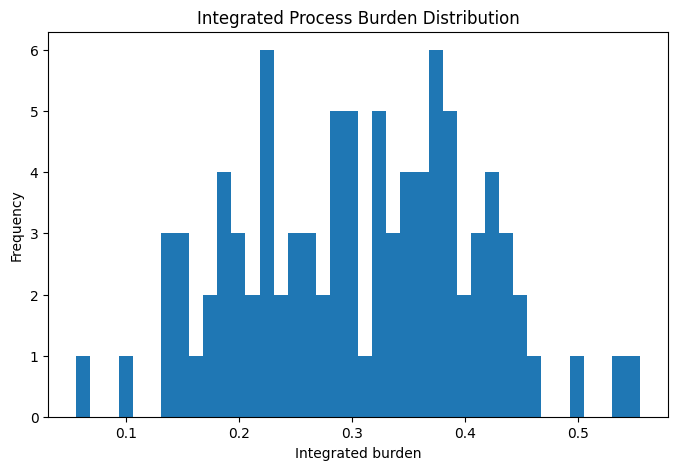

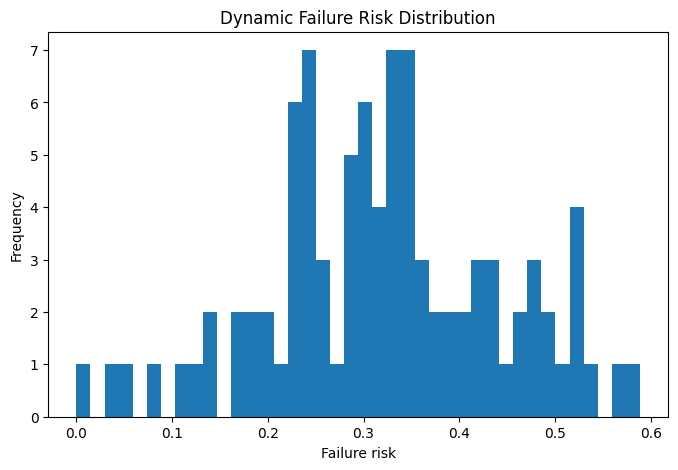

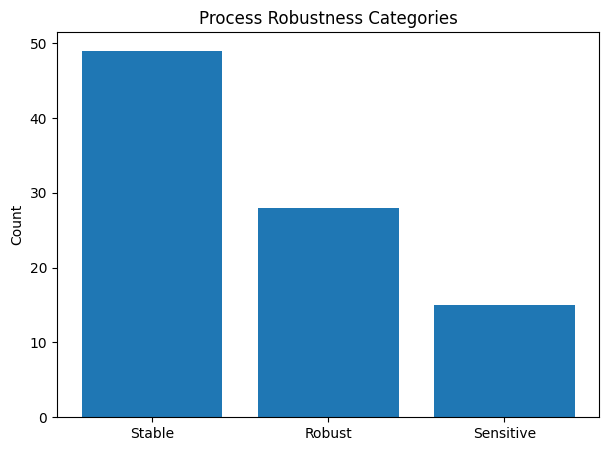

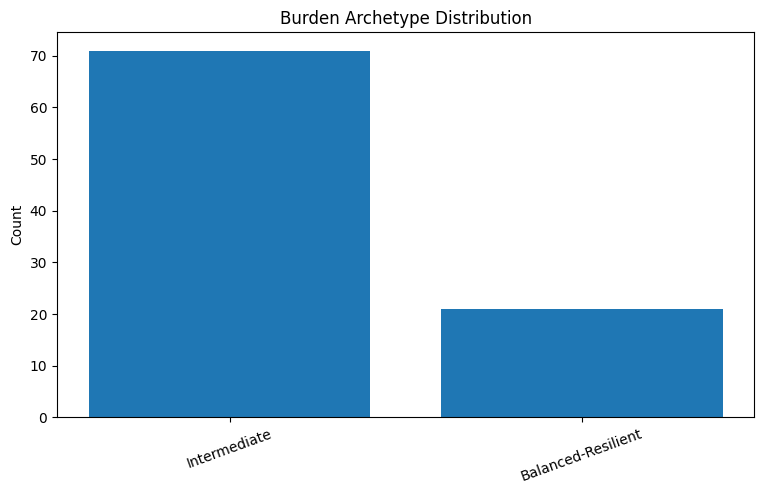

In [10]:
# ----------------------------------------
# Integrated burden distribution
# ----------------------------------------

plt.figure(figsize=(8,5))

plt.hist(
    final_df["integrated_process_burden"],
    bins=40
)

plt.title("Integrated Process Burden Distribution")

plt.xlabel("Integrated burden")

plt.ylabel("Frequency")

plt.show()

# ----------------------------------------
# Failure risk distribution
# ----------------------------------------

plt.figure(figsize=(8,5))

plt.hist(
    final_df["dynamic_failure_risk"],
    bins=40
)

plt.title("Dynamic Failure Risk Distribution")

plt.xlabel("Failure risk")

plt.ylabel("Frequency")

plt.show()

# ----------------------------------------
# Robustness categories
# ----------------------------------------

robust_counts = (
    final_df["process_robustness"]
    .value_counts()
)

plt.figure(figsize=(7,5))

plt.bar(
    robust_counts.index,
    robust_counts.values
)

plt.title("Process Robustness Categories")

plt.ylabel("Count")

plt.show()

# ----------------------------------------
# Archetype categories
# ----------------------------------------

arch_counts = (
    final_df["burden_archetype"]
    .value_counts()
)

plt.figure(figsize=(9,5))

plt.bar(
    arch_counts.index,
    arch_counts.values
)

plt.xticks(rotation=20)

plt.title("Burden Archetype Distribution")

plt.ylabel("Count")

plt.show()

## Section 11 — Export burden realism outputs

This section exports burden-state simulation outputs for downstream realism calibration and multi-omics simulation.

In [11]:
OUT_DIR = ROOT / "data" / "synthetic" / "process"

OUT_DIR.mkdir(parents=True, exist_ok=True)

EXPORT_PATH = (
    OUT_DIR
    / "notebook12_process_burden_simulation_5000_legacy.csv"
)

final_df.to_csv(EXPORT_PATH, index=False)

print(EXPORT_PATH)

/Users/sang/CLD_ML_PIPELINE/data/synthetic/process/notebook12_process_burden_simulation_5000_legacy.csv


# Final Summary

## Notebook12 expanded the simulator from phenotype-level optimization toward mechanistic process realism.

Major additions included:

* lactate burden simulation
* ammonia burden simulation
* oxidative stress modeling
* ER stress burden
* nutrient depletion pressure
* integrated process burden scoring
* dynamic process failure risk
* process robustness classification
* burden-aware rescue feasibility

The simulator now represents:

* clone productivity
* quality behavior
* glycosylation realism
* process burden propagation
* biological fragility
* hidden process instability

within one unified virtual CHO process system.

This notebook establishes the foundation for:

* metabolomics realism
* systems-biology calibration
* dynamic state simulation
* multi-omics latent modeling
* digital twin evolution

in future notebooks.